#Single-Cell RNA-Seq Analysis of Cancer Immune Microenvironment
 Pradip Palekar
 Institute: IIIT Delhi, M.Tech Computational Biology
 Date: May 2026

STEP 1: Install Libraries

In [1]:
!pip install scanpy leidenalg matplotlib seaborn pandas numpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 117.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 25.2 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take in

STEP 2: Import

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


 STEP 3: Load the PBMC 3k Dataset

In [3]:
print("\nDownloading PBMC 3k dataset from 10x Genomics...")
adata = sc.datasets.pbmc3k()

print(f"\nDataset loaded!")
print(f"Cells: {adata.n_obs}")
print(f"Genes: {adata.n_vars}")
print(f"Matrix shape: {adata.X.shape}")
print(f"\nThis is a {adata.n_obs} cells × {adata.n_vars} genes expression matrix")
print(f"Each row = one cell, each column = one gene")
print(f"\nFirst few genes: {list(adata.var_names[:10])}")

  0%|          | 0.00/5.58M [00:00<?, ?B/s]


Dataset loaded!
Cells: 2700
Genes: 32738
Matrix shape: (2700, 32738)

This is a 2700 cells × 32738 genes expression matrix
Each row = one cell, each column = one gene

First few genes: ['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8', 'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9', 'AP006222.2', 'RP4-669L17.10']


 STEP 4: Quality Control (QC)


In [4]:
print("\n--- QUALITY CONTROL ---")

# Calculate QC metrics
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # mitochondrial genes
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)


--- QUALITY CONTROL ---


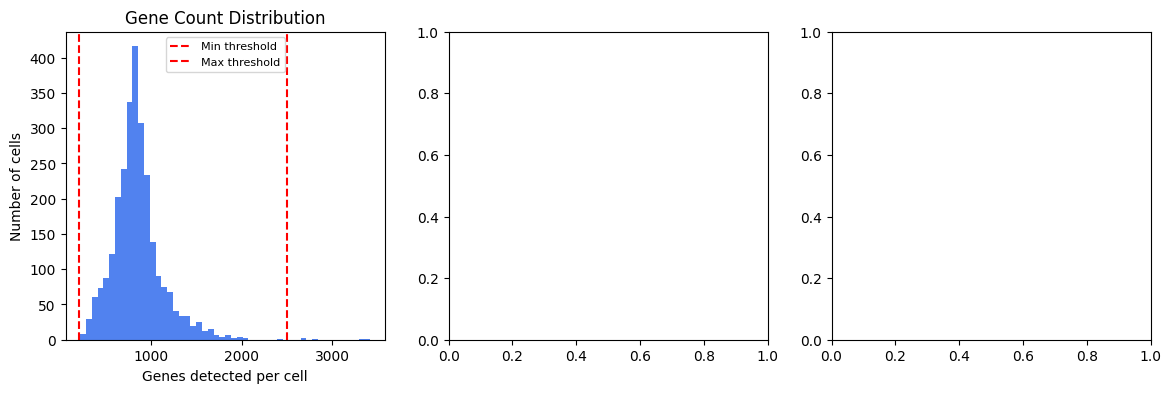

In [5]:
# Plot QC metrics
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(adata.obs['n_genes_by_counts'], bins=50, color='#2563eb', alpha=0.8)
axes[0].set_xlabel('Genes detected per cell')
axes[0].set_ylabel('Number of cells')
axes[0].set_title('Gene Count Distribution')
axes[0].axvline(200, color='red', linestyle='--', label='Min threshold')
axes[0].axvline(2500, color='red', linestyle='--', label='Max threshold')
axes[0].legend(fontsize=8)

In [11]:
axes[1].hist(adata.obs['total_counts'], bins=50, color='#16a34a', alpha=0.8)
axes[1].set_xlabel('Total UMI counts per cell')
axes[1].set_ylabel('Number of cells')
axes[1].set_title('UMI Count Distribution')

Text(0.5, 1.0, 'UMI Count Distribution')

In [12]:
axes[2].hist(adata.obs['pct_counts_mt'], bins=50, color='#dc2626', alpha=0.8)
axes[2].set_xlabel('% Mitochondrial genes')
axes[2].set_ylabel('Number of cells')
axes[2].set_title('Mitochondrial Content')
axes[2].axvline(5, color='black', linestyle='--', label='Threshold (5%)')
axes[2].legend(fontsize=8)

In [13]:
plt.suptitle('Quality Control Metrics — Before Filtering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('qc_before_filtering.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved qc_before_filtering.png")

<Figure size 640x480 with 0 Axes>

Saved qc_before_filtering.png


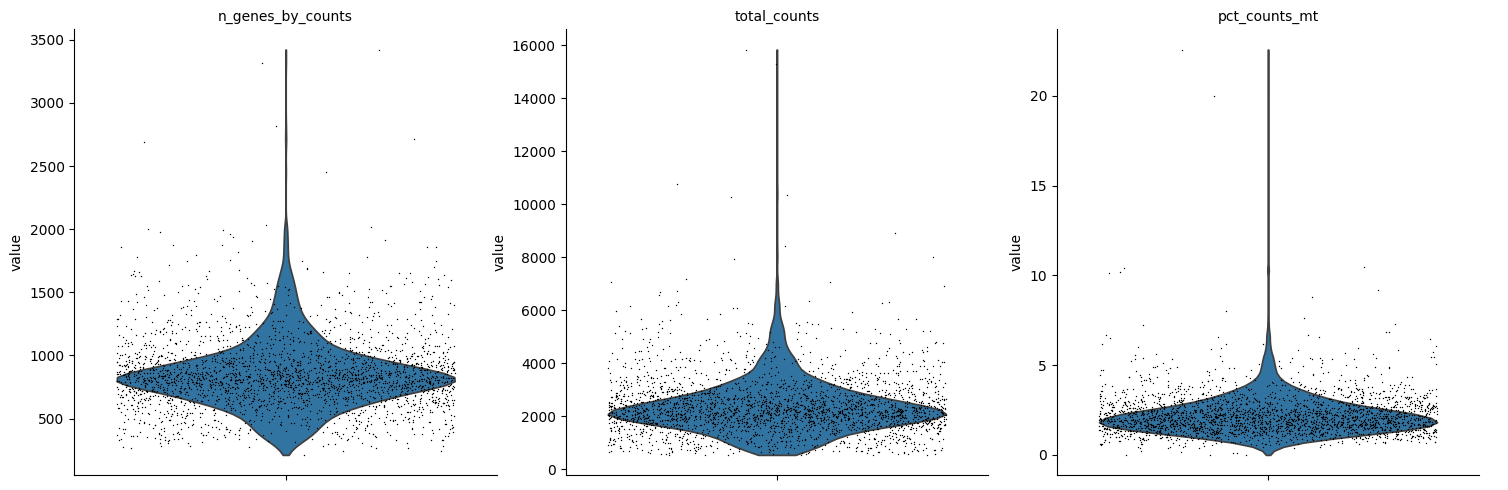


Before filtering: 2700 cells, 32738 genes


In [14]:
# Violin plots
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, save='_qc_violin.png')

print(f"\nBefore filtering: {adata.n_obs} cells, {adata.n_vars} genes")

 STEP 5: Filter Low-Quality Cells and Genes


In [15]:

# Filter cells
sc.pp.filter_cells(adata, min_genes=200)        # cells with at least 200 genes
sc.pp.filter_genes(adata, min_cells=3)           # genes in at least 3 cells

# Remove cells with too many genes (possible doublets)
adata = adata[adata.obs.n_genes_by_counts < 2500, :]

# Remove cells with high mitochondrial content (dying cells)
adata = adata[adata.obs.pct_counts_mt < 5, :]

print(f"After filtering: {adata.n_obs} cells, {adata.n_vars} genes")
print(f"Removed low-quality cells and rarely expressed genes")


After filtering: 2638 cells, 13714 genes
Removed low-quality cells and rarely expressed genes


 STEP 6: Normalization and Log Transform

In [18]:
# Normalize each cell to have 10,000 total counts
# Then log-transform to stabilize variance

print("\nNormalizing and log-transforming...")

adata.raw = adata.copy()

# Normalize to 10,000 counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)

# Log transform
sc.pp.log1p(adata)

print("Normalization complete")


Normalizing and log-transforming...
Normalization complete


STEP 7: Feature Selection — Highly Variable Genes (HVGs)


Found 3189 highly variable genes out of 13714


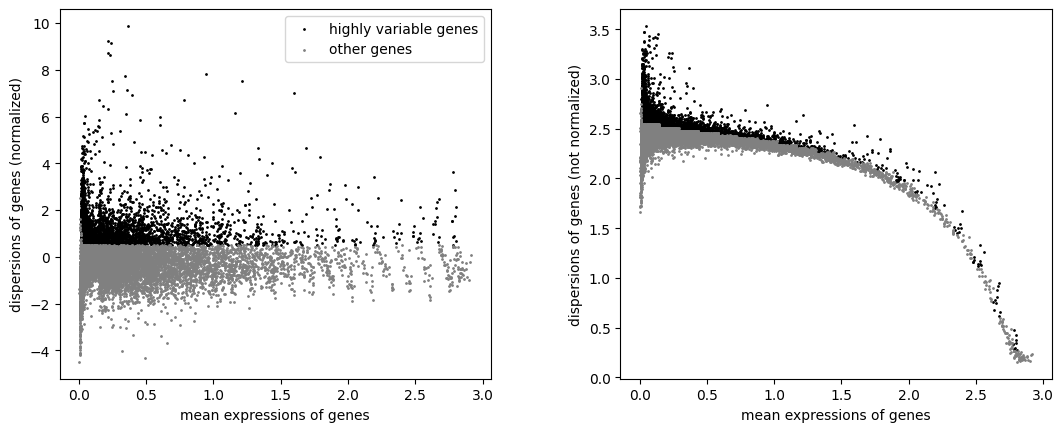

Filtered to 3189 HVGs


In [19]:
#Select the most variable ones for downstream analysis

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

n_hvg = adata.var.highly_variable.sum()
print(f"\nFound {n_hvg} highly variable genes out of {adata.n_vars}")

sc.pl.highly_variable_genes(adata, save='_hvg.png')

# Keep only HVGs for downstream analysis
adata = adata[:, adata.var.highly_variable]
print(f"Filtered to {adata.n_vars} HVGs")

 STEP 8: Scale and PCA



Scaling data and running PCA...


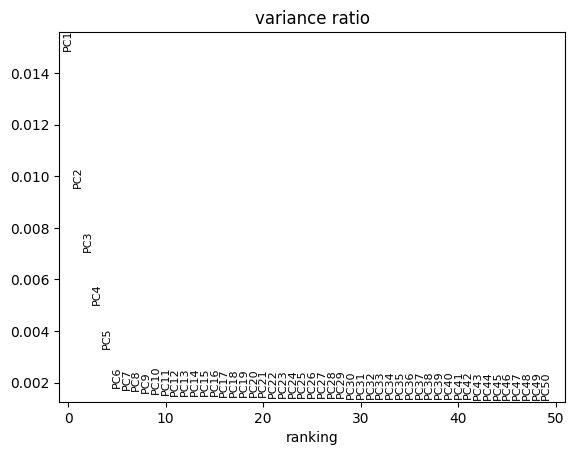

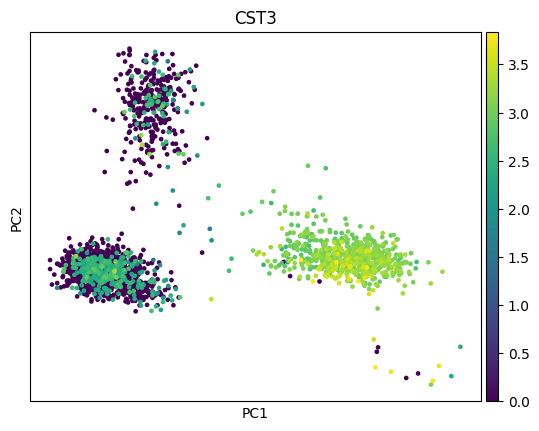

PCA complete: 3189 genes → 50 PCs


In [20]:
print("\nScaling data and running PCA...")

# Scale each gene
sc.pp.scale(adata, max_value=10)

# PCA
sc.tl.pca(adata, svd_solver='arpack', n_comps=50)

# Plot variance
sc.pl.pca_variance_ratio(adata, n_pcs=50, save='_variance.png')

# Plot PCA
sc.pl.pca(adata, color='CST3', save='_pca.png')

print(f"PCA complete: {adata.n_vars} genes → 50 PCs")

STEP 9: Build Neighborhood Graph

In [21]:
# Find nearest neighbors in PCA space
# This is the foundation for clustering and UMAP
print("\nBuilding neighborhood graph...")
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
print("Neighborhood graph computed (k=10, 40 PCs)")


Building neighborhood graph...
Neighborhood graph computed (k=10, 40 PCs)


STEP 10: UMAP Embedding

In [22]:
print("\nComputing UMAP embedding...")
sc.tl.umap(adata)
print("UMAP complete!")


Computing UMAP embedding...
UMAP complete!


STEP 11: Clustering with Leiden Algorithm


Clustering cells with Leiden algorithm...
Found 7 clusters


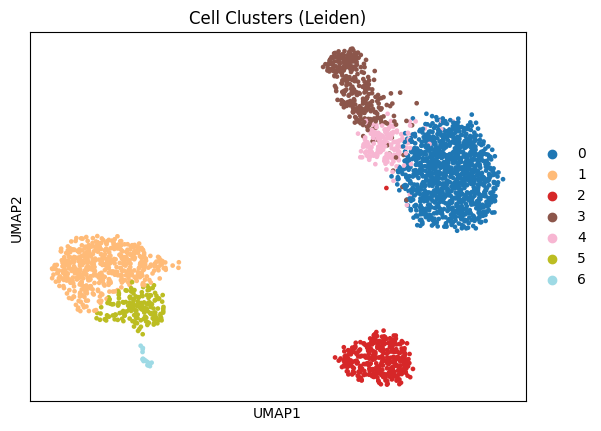

In [23]:
#Identify distinct cell populations (clusters)
# Each cluster = a potential cell type

print("\nClustering cells with Leiden algorithm...")
sc.tl.leiden(adata, resolution=0.9)

n_clusters = len(adata.obs['leiden'].unique())
print(f"Found {n_clusters} clusters")

# Plot UMAP with clusters
sc.pl.umap(adata, color='leiden', title='Cell Clusters (Leiden)',
          palette='tab20', save='_clusters.png')


STEP 12: Find Marker Genes for Each Cluster


Finding marker genes for each cluster...

Top 5 marker genes per cluster:
       0       1         2     3     4       5      6
0   LDHB     LYZ      CD74  NKG7  CCL5    LST1   PPBP
1   CD3D    CST3   HLA-DRA  CST7  GZMK  FCER1G   GPX1
2   CD3E  S100A9     CD79A  GZMA  NKG7  FCGR3A   SDPR
3  RPS25  TYROBP  HLA-DPB1  CTSW  IL32  IFITM3    PF4
4   TPT1  S100A8     CD79B  GZMB  GZMA    AIF1  SPARC


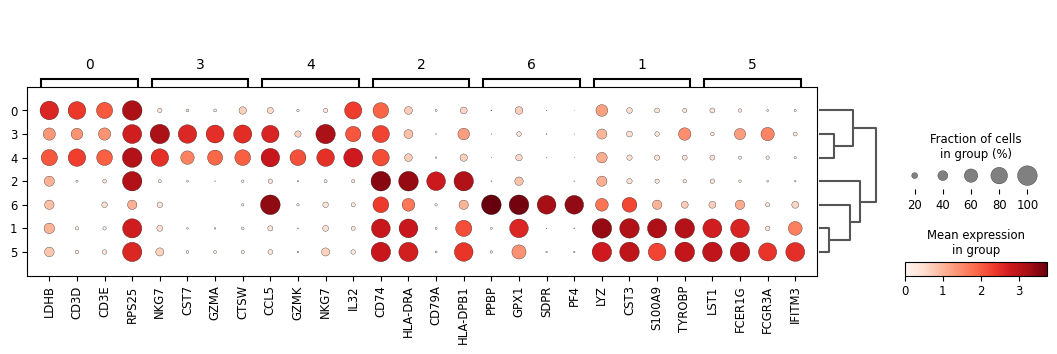

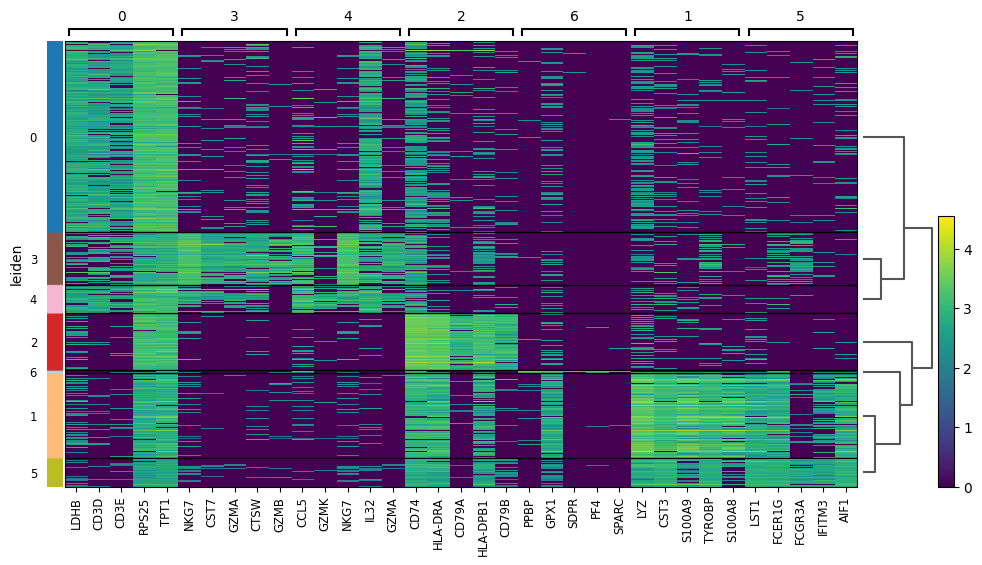

In [24]:
print("\nFinding marker genes for each cluster...")
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

# Show top 5 markers per cluster
result = adata.uns['rank_genes_groups']
top_markers = pd.DataFrame({
    group: [result['names'][i][group] for i in range(5)]
    for group in result['names'].dtype.names
})
print("\nTop 5 marker genes per cluster:")
print(top_markers.to_string())

# Dot plot of top markers
sc.pl.rank_genes_groups_dotplot(adata, n_genes=4, save='_markers_dotplot.png')

# Heatmap of top markers
sc.pl.rank_genes_groups_heatmap(adata, n_genes=5, save='_markers_heatmap.png')

STEP 13: Cell Type Annotation


Annotating cell types using known markers...


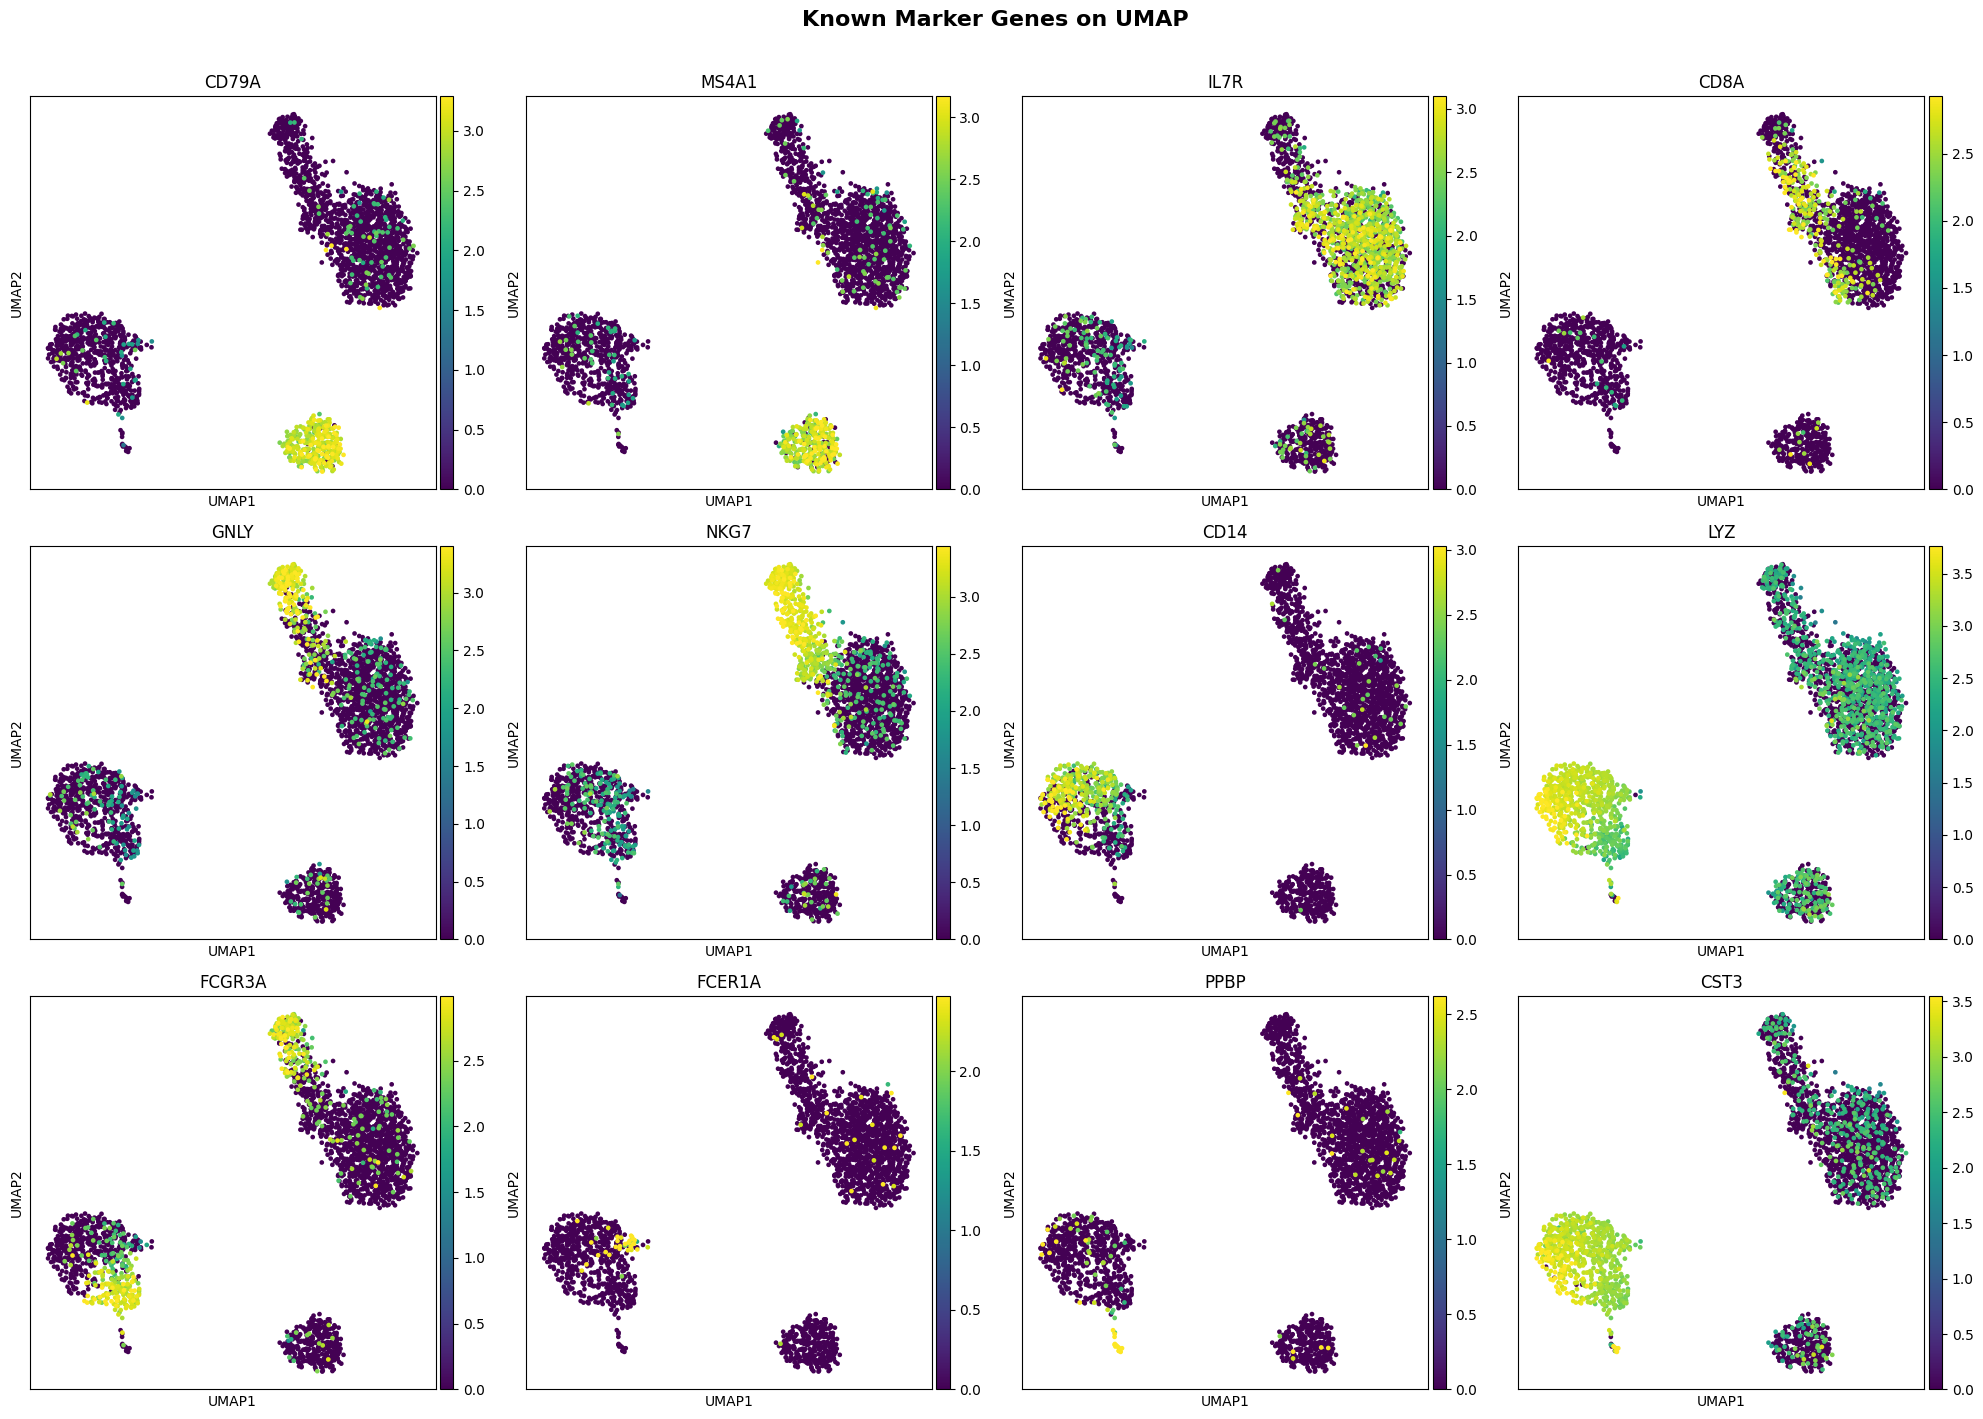

Saved marker_genes_umap.png


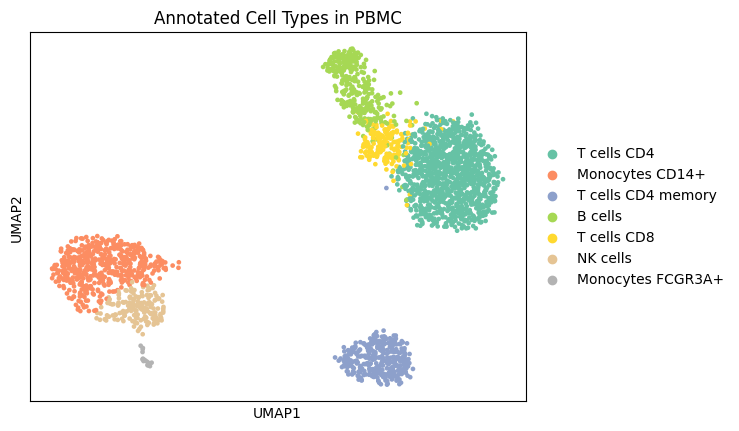

In [26]:
print("\nAnnotating cell types using known markers...")

# Known marker genes for blood cell types
marker_genes = {
    'B cells': ['CD79A', 'MS4A1', 'CD79B'],
    'T cells CD4': ['IL7R', 'CD4'],
    'T cells CD8': ['CD8A', 'CD8B'],
    'NK cells': ['GNLY', 'NKG7', 'KLRD1'],
    'Monocytes CD14+': ['CD14', 'LYZ', 'S100A9'],
    'Monocytes FCGR3A+': ['FCGR3A', 'MS4A7'],
    'Dendritic cells': ['FCER1A', 'CST3'],
    'Platelets': ['PPBP', 'PF4'],
}

# Plot known markers on UMAP
marker_list = ['CD79A', 'MS4A1', 'IL7R', 'CD8A', 'GNLY', 'NKG7',
               'CD14', 'LYZ', 'FCGR3A', 'FCER1A', 'PPBP', 'CST3']

# Filter markers that exist in our data
existing_markers = [m for m in marker_list if m in adata.raw.var_names]

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for idx, gene in enumerate(existing_markers):
    if idx < len(axes):
        sc.pl.umap(adata, color=gene, use_raw=True, ax=axes[idx],
                   show=False, title=gene, vmax='p99')

# Remove empty subplots
for idx in range(len(existing_markers), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Known Marker Genes on UMAP', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('marker_genes_umap.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved marker_genes_umap.png")

# Manual annotation based on marker expression
# This mapping will depend on your specific clustering results
# Check which cluster expresses which markers
new_cluster_names = {
    '0': 'T cells CD4',
    '1': 'Monocytes CD14+',
    '2': 'T cells CD4 memory',
    '3': 'B cells',
    '4': 'T cells CD8',
    '5': 'NK cells',
    '6': 'Monocytes FCGR3A+',
    '7': 'Dendritic cells',
}

# Apply annotation (map only clusters that exist)
adata.obs['cell_type'] = adata.obs['leiden'].map(
    lambda x: new_cluster_names.get(x, f'Cluster {x}')
)

# Final annotated UMAP
sc.pl.umap(adata, color='cell_type',
          title='Annotated Cell Types in PBMC',
          palette='Set2', save='_cell_types.png')

STEP 14: Cell Type Proportions

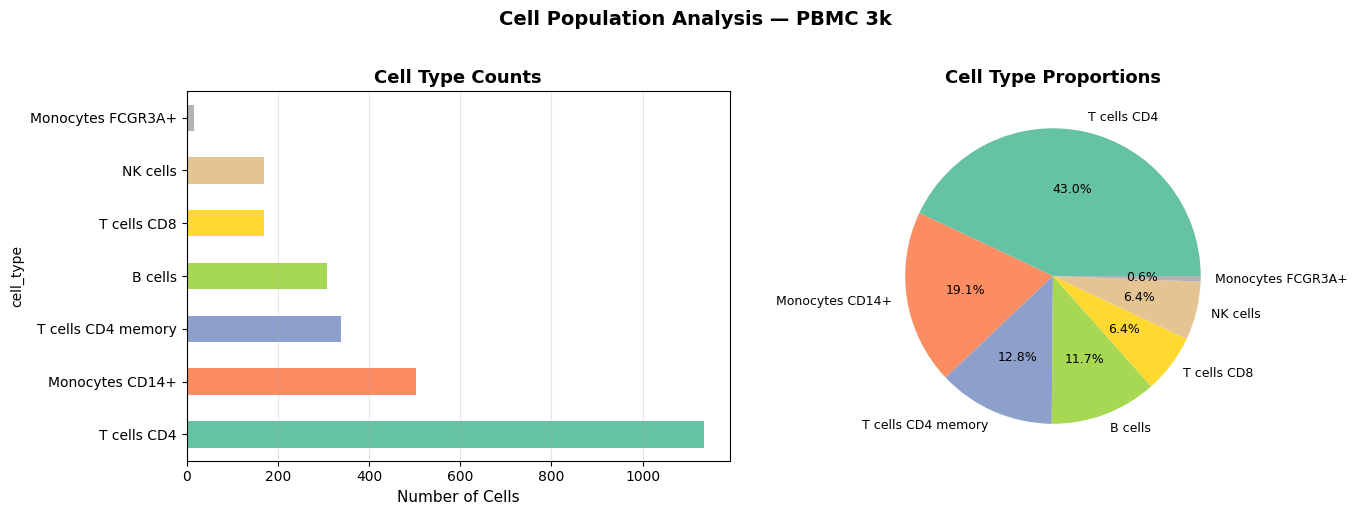

Saved cell_type_proportions.png


In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
cell_counts = adata.obs['cell_type'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(cell_counts)))
cell_counts.plot(kind='barh', color=colors, ax=ax1)
ax1.set_xlabel('Number of Cells', fontsize=11)
ax1.set_title('Cell Type Counts', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Pie chart
cell_counts.plot(kind='pie', colors=colors, ax=ax2, autopct='%1.1f%%',
                 textprops={'fontsize': 9})
ax2.set_ylabel('')
ax2.set_title('Cell Type Proportions', fontsize=13, fontweight='bold')

plt.suptitle('Cell Population Analysis — PBMC 3k', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cell_type_proportions.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved cell_type_proportions.png")

STEP 15: Differential Expression Between Cell Types


Running differential expression: T cells vs Monocytes...


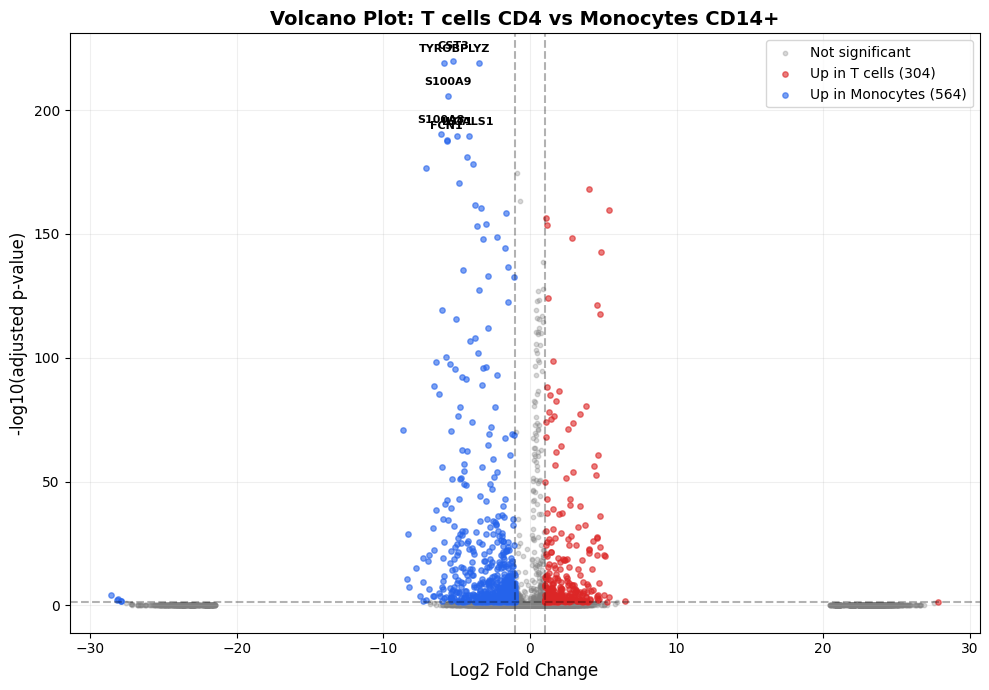

Saved volcano_plot.png


In [28]:
print("\nRunning differential expression: T cells vs Monocytes...")

# Compare T cells CD4 vs Monocytes
sc.tl.rank_genes_groups(adata, 'cell_type', groups=['T cells CD4'],
                        reference='Monocytes CD14+', method='wilcoxon')

# Volcano plot
result = adata.uns['rank_genes_groups']
de_genes = pd.DataFrame({
    'gene': result['names']['T cells CD4'],
    'logFC': result['logfoldchanges']['T cells CD4'],
    'pval': result['pvals']['T cells CD4'],
    'pval_adj': result['pvals_adj']['T cells CD4'],
})

de_genes['-log10p'] = -np.log10(de_genes['pval_adj'] + 1e-300)

plt.figure(figsize=(10, 7))
# Not significant
mask_ns = (abs(de_genes['logFC']) < 1) | (de_genes['-log10p'] < -np.log10(0.05))
plt.scatter(de_genes.loc[mask_ns, 'logFC'], de_genes.loc[mask_ns, '-log10p'],
           c='grey', alpha=0.3, s=10, label='Not significant')

# Up in T cells
mask_up = (de_genes['logFC'] > 1) & (de_genes['-log10p'] > -np.log10(0.05))
plt.scatter(de_genes.loc[mask_up, 'logFC'], de_genes.loc[mask_up, '-log10p'],
           c='#dc2626', alpha=0.6, s=15, label=f'Up in T cells ({mask_up.sum()})')

# Down in T cells (up in Monocytes)
mask_down = (de_genes['logFC'] < -1) & (de_genes['-log10p'] > -np.log10(0.05))
plt.scatter(de_genes.loc[mask_down, 'logFC'], de_genes.loc[mask_down, '-log10p'],
           c='#2563eb', alpha=0.6, s=15, label=f'Up in Monocytes ({mask_down.sum()})')

# Label top genes
top_genes = de_genes.nlargest(8, '-log10p')
for _, row in top_genes.iterrows():
    plt.annotate(row['gene'], (row['logFC'], row['-log10p']),
                fontsize=8, fontweight='bold', ha='center',
                xytext=(0, 8), textcoords='offset points')

plt.xlabel('Log2 Fold Change', fontsize=12)
plt.ylabel('-log10(adjusted p-value)', fontsize=12)
plt.title('Volcano Plot: T cells CD4 vs Monocytes CD14+', fontsize=14, fontweight='bold')
plt.axhline(-np.log10(0.05), color='black', linestyle='--', alpha=0.3)
plt.axvline(-1, color='black', linestyle='--', alpha=0.3)
plt.axvline(1, color='black', linestyle='--', alpha=0.3)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('volcano_plot.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved volcano_plot.png")

 STEP 16: Summary

In [29]:
print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)
print(f"Dataset: PBMC 3k (10x Genomics)")
print(f"Cells after QC: {adata.n_obs}")
print(f"Genes (HVGs): {adata.n_vars}")
print(f"Clusters found: {n_clusters}")
print(f"Cell types annotated: {len(new_cluster_names)}")
print(f"")
print(f"Pipeline: Raw counts → QC → Normalization → HVG →")
print(f"  PCA → Neighbors → UMAP → Leiden clustering →")
print(f"  Marker genes → Cell type annotation → DE analysis")
print(f"")
print(f"Files saved:")
print(f"  - qc_before_filtering.png")
print(f"  - marker_genes_umap.png")
print(f"  - cell_type_proportions.png")
print(f"  - volcano_plot.png")
print(f"  + Scanpy auto-saved figures in 'figures/' folder")
print(f"")
print(f"Author: Pradip Palekar (MT25215)")
print(f"IIIT Delhi, M.Tech Computational Biology")
print("=" * 60)


PROJECT SUMMARY
Dataset: PBMC 3k (10x Genomics)
Cells after QC: 2638
Genes (HVGs): 3189
Clusters found: 7
Cell types annotated: 8

Pipeline: Raw counts → QC → Normalization → HVG →
  PCA → Neighbors → UMAP → Leiden clustering →
  Marker genes → Cell type annotation → DE analysis

Files saved:
  - qc_before_filtering.png
  - marker_genes_umap.png
  - cell_type_proportions.png
  - volcano_plot.png
  + Scanpy auto-saved figures in 'figures/' folder

Author: Pradip Palekar (MT25215)
IIIT Delhi, M.Tech Computational Biology


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>